# LAB09 · Análisis de resultados
Ejecutar primero en la terminal, desde la raíz del proyecto, las seis corridas de `scripts/lab09_hybrid.py` (alpha 0.25 y 0.75 con las semillas 11, 42 y 73, ver README) y después `uv run python scripts/lab09_pareto.py`.

Luego ejecutar las celdas para visualizar los datos reales de `reports/`.

In [1]:
from pathlib import Path
import json
import pandas as pd
from IPython.display import display

# Localizar la carpeta reports desde la raíz o desde notebooks/
reports = next((ruta for ruta in [Path("reports"), Path("../reports")] if ruta.is_dir()), None)
archivos = sorted(reports.glob("lab09_seed*_alpha*.json")) if reports else []
if not archivos:
    raise FileNotFoundError(
        "No se encontraron reports/lab09_seed*_alpha*.json. "
        "Ejecuta primero las corridas de scripts/lab09_hybrid.py indicadas en el README"
    )

# Cargar una fila por corrida (semilla y alpha)
df = pd.DataFrame([json.loads(archivo.read_text(encoding="utf-8")) for archivo in archivos])
df = df[["seed", "factors", "epochs", "alpha", "rmse", "hit_rate_at_10", "precision_at_10",
         "catalog_coverage", "train_seconds", "model_size_bytes", "evaluated_users"]]

print("Carpeta de resultados:", reports.resolve())
print("Cantidad de experimentos:", len(df))
display(df)

Carpeta de resultados: C:\Users\Administrator\Desktop\Maestria_Big_Data\11_INF-8239_Ciencias_de_Datos_II\INF8239_U03\reports
Cantidad de experimentos: 6


,seed,factors,epochs,alpha,rmse,hit_rate_at_10,precision_at_10,catalog_coverage,train_seconds,model_size_bytes,evaluated_users
0,11,20,12,0.25,1.024542,0.032368,0.003237,0.103185,22.522565,1649760,587
1,11,20,12,0.75,1.024542,0.032368,0.003237,0.076384,20.391516,1649760,587
2,42,20,12,0.25,1.026418,0.032368,0.003237,0.106484,19.902209,1649760,587
3,42,20,12,0.75,1.026418,0.037479,0.003748,0.077518,19.743105,1649760,587
4,73,20,12,0.25,1.033118,0.028961,0.002896,0.109164,20.460829,1649760,587
5,73,20,12,0.75,1.033118,0.028961,0.002896,0.081847,20.549144,1649760,587


In [2]:
display(df.groupby("alpha")[["rmse", "hit_rate_at_10", "catalog_coverage", "train_seconds"]].agg(["mean", "std"]))

rmse           hit_rate_at_10           catalog_coverage            \
           mean       std           mean       std             mean       std   
alpha                                                                           
0.25   1.028026  0.004508       0.031232  0.001967         0.106278  0.002995   
0.75   1.028026  0.004508       0.032936  0.004287         0.078583  0.002883   

      train_seconds            
               mean       std  
alpha                          
0.25      20.961868  1.380161  
0.75      20.227922  0.427197

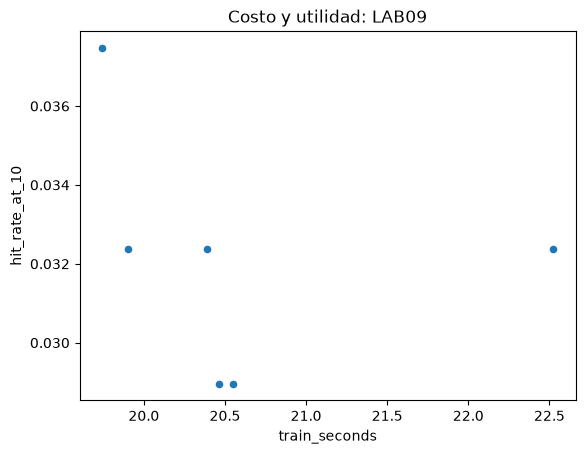

In [3]:
import matplotlib.pyplot as plt
ax = df.plot.scatter(x="train_seconds", y="hit_rate_at_10", title="Costo y utilidad: LAB09")
plt.show()

## Comparación de modelos
Popularidad, contenido, colaborativo e híbrido con la misma partición; media de las semillas 11, 42 y 73 e IC95 de Wilson del HitRate@10.

Estos archivos provienen de un script exploratorio de comparación que no forma parte de la entrega; se conservan como evidencia y no se regeneran con los comandos del repositorio.

In [4]:
resumen = pd.read_csv(reports / "comparacion_modelos_resumen.csv")
display(resumen[["modelo", "rmse", "hit_rate_at_10", "hit_rate_ic95_bajo", "hit_rate_ic95_alto",
                 "catalog_coverage", "costo_total_seconds"]].round(4))

,modelo,rmse,hit_rate_at_10,hit_rate_ic95_bajo,hit_rate_ic95_alto,catalog_coverage,costo_total_seconds
0,popularidad_cantidad,NaN,0.0426,0.0290,0.0621,0.0122,0.0053
1,popularidad_ponderada,NaN,0.0324,0.0208,0.0500,0.0063,0.0020
2,contenido_perfil,NaN,0.0017,0.0003,0.0096,0.0778,3.0799
3,colaborativo,1.028,0.0335,0.0217,0.0514,0.0753,44.0468
4,hibrido_a0.25,1.028,0.0312,0.0199,0.0486,0.1063,48.2268
5,hibrido_a0.75,1.028,0.0329,0.0213,0.0507,0.0786,48.7520


,modelo,hit_rate_at_10,catalog_coverage,costo_total_seconds,dominado_por,pareto_optimo
0,popularidad_cantidad,0.0426,0.0122,0.0053,NaN,True
1,popularidad_ponderada,0.0324,0.0063,0.0020,popularidad_cantidad,False
2,contenido_perfil,0.0017,0.0778,3.0799,NaN,True
3,colaborativo,0.0335,0.0753,44.0468,NaN,True
4,hibrido_a0.25,0.0312,0.1063,48.2268,NaN,True
5,hibrido_a0.75,0.0329,0.0786,48.7520,NaN,True


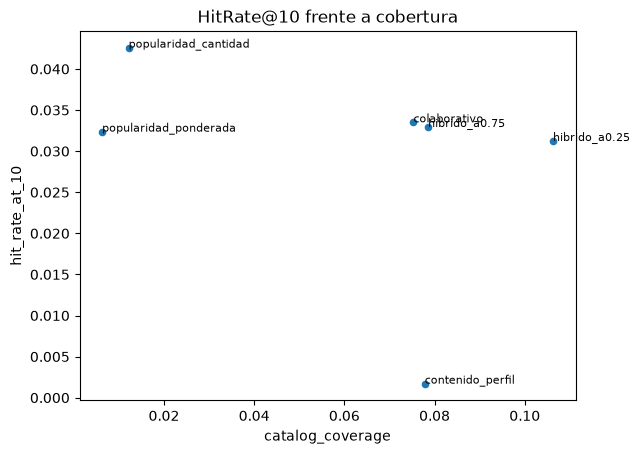

In [5]:
pareto = pd.read_csv(reports / "pareto_modelos.csv")
display(pareto.round(4))
ax = pareto.plot.scatter(x="catalog_coverage", y="hit_rate_at_10", title="HitRate@10 frente a cobertura")
for fila in pareto.itertuples():
    ax.annotate(fila.modelo, (fila.catalog_coverage, fila.hit_rate_at_10), fontsize=8)
plt.show()

## Perfiles de historial y usuario frío

In [6]:
perfiles = pd.read_csv(reports / "comparacion_perfiles.csv")
display(perfiles.pivot(index="modelo", columns="perfil", values="hit_rate_at_10").round(4))
frio = json.loads((reports / "usuario_frio.json").read_text(encoding="utf-8"))
print(f"Usuario nuevo: HitRate@10 = {frio['hit_rate_at_10']:.3f}, cobertura = {frio['catalog_coverage']:.4f}")
print("Top-10 de respaldo:", ", ".join(frio["top10"]))

perfil,historial_medio,mucho_historial,poco_historial
modelo,,,
colaborativo,0.0430,0.0204,0.0372
contenido_perfil,0.0000,0.0000,0.0051
hibrido_a0.25,0.0206,0.0187,0.0541
hibrido_a0.75,0.0395,0.0136,0.0457
popularidad_cantidad,0.0515,0.0204,0.0558
popularidad_ponderada,0.0515,0.0102,0.0355


Usuario nuevo: HitRate@10 = 0.020, cobertura = 0.0010
Top-10 de respaldo: Forrest Gump (1994), Shawshank Redemption, The (1994), Pulp Fiction (1994), Matrix, The (1999), Silence of the Lambs, The (1991), Star Wars: Episode IV - A New Hope (1977), Braveheart (1995), Jurassic Park (1993), Terminator 2: Judgment Day (1991), Fight Club (1999)


## Interpretación

**RMSE.** La factorización (20 factores, 12 épocas) obtuvo 1.025, 1.026 y 1.033 con las semillas 11, 42 y 73 (media 1.028). Alpha no cambia el RMSE porque solo afecta el ranking. El valor es cercano a la desviación estándar de los ratings (1.04), por lo que la mejora sobre una predicción constante es pequeña.

**Ranking.** Con 587 usuarios y leave-one-out temporal, el HitRate@10 medio fue: popularidad por cantidad 4.3 % (IC95 2.9–6.2), colaborativo 3.4 % (2.2–5.1), híbrido alpha 0.75 3.3 %, popularidad ponderada 3.2 %, híbrido alpha 0.25 3.1 % (2.0–4.9) y contenido 0.2 %. Los intervalos se solapan: el modelo personalizado no demuestra superar a popularidad.

**Cobertura.** Popularidad cubre el 1.2 % del catálogo; colaborativo 7.5 %, híbrido alpha 0.75 7.9 % e híbrido alpha 0.25 10.6 % (unas 8.7 veces popularidad). Bajar alpha aumentó la cobertura alrededor de un 35 % con un hit rate equivalente.

**Cold start.** Un usuario nuevo recibe el Top-10 por cantidad y media: acierta el 2.0 % (12 de 587) y cubre el 0.1 % del catálogo. Con poco historial, popularidad (5.6 %) y el híbrido alpha 0.25 (5.4 %) superan al colaborativo solo (3.7 %), con unos 197 usuarios por grupo (tendencia). Un título desconocido en la consulta por contenido recibe ahora el Top-10 de popularidad como respaldo.

**Decisión Pareto.** Con HitRate@10, cobertura y costo total (tolerancia de 1 s), cinco de seis modelos quedan en el frente; solo popularidad ponderada es dominada por popularidad por cantidad. Se selecciona el híbrido (factors=20, epochs=12, alpha=0.25) con popularidad por cantidad como respaldo: cubre el 10.6 % del catálogo con una diferencia de hit rate no concluyente frente a popularidad (unos 7 de 587 usuarios). Límites: candidatos restringidos a los 100 mejores colaborativos, un solo ítem retenido por usuario y tiempos que varían entre corridas.